# Step Response Analysis (Problem L6.4)

This notebook compares measured and theoretical step responses using data from lab6.csv.

Step index: 128
10%-90% rise time: 9.00 ms
Estimated zeta: 0.610
Estimated wn: 200.0 rad/s


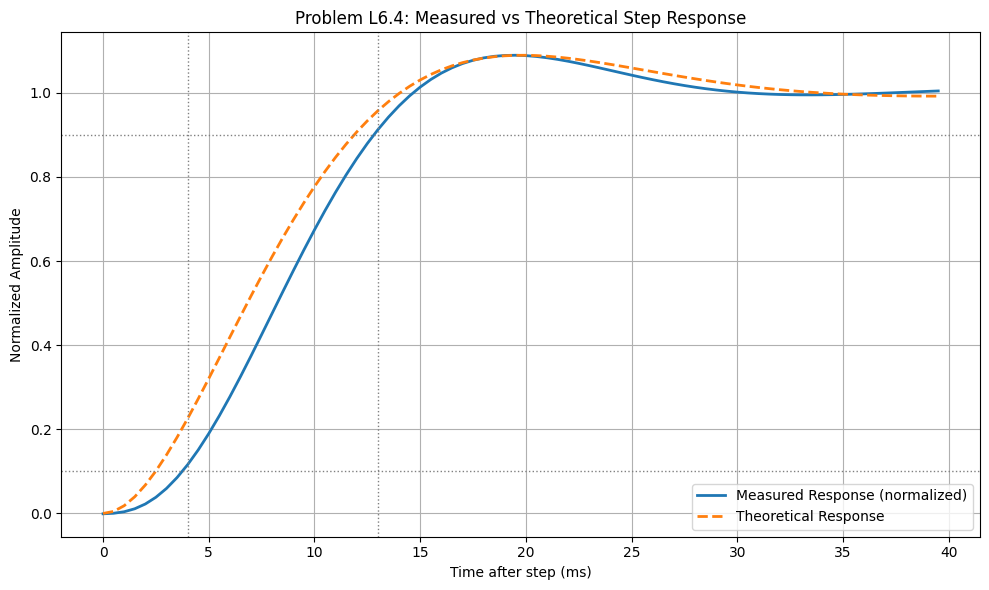

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --------------------------------------------------
# Load CSV data
# --------------------------------------------------
df = pd.read_csv("lab6.csv")

# Convert ms -> s for a physically meaningful time axis
t = df["t"].to_numpy() / 1000.0
x = df["x"].to_numpy()
y = df["y"].to_numpy()

# --------------------------------------------------
# Detect a major rising input edge
# --------------------------------------------------
dx = np.diff(x)
threshold = 0.5 * np.max(np.abs(dx))
edge_indices = np.where(np.abs(dx) >= threshold)[0]
rising_indices = np.where(dx >= threshold)[0]

if len(rising_indices) > 0:
    # Use the strongest rising edge (best match to 10%-90% rise-time measurement)
    step_index = rising_indices[np.argmax(dx[rising_indices])]
else:
    # Fallback: strongest edge regardless of direction
    step_index = edge_indices[np.argmax(np.abs(dx[edge_indices]))]

# Build a window around the step and avoid the next transition in the square wave
start = max(step_index - 20, 0)
default_end = min(step_index + 80, len(t) - 1)

next_edges = edge_indices[edge_indices > step_index + 5]
if len(next_edges) > 0:
    guard = max(10, int(0.8 * (next_edges[0] - step_index)))
    end = min(step_index + guard, default_end)
else:
    end = default_end

t_raw = t[start:end + 1]
y_raw = y[start:end + 1]

# Local index where the new step level starts
local_step_idx = (step_index + 1) - start

# --------------------------------------------------
# Normalize measured response to 0 -> 1
# --------------------------------------------------
pre_slice_start = max(local_step_idx - 10, 0)
y_initial = np.mean(y_raw[pre_slice_start:local_step_idx])
y_final = np.mean(y_raw[-10:])
y_measured = (y_raw - y_initial) / (y_final - y_initial)

# Use post-step data for direct comparison with a unit-step model
t_step = t_raw[local_step_idx:] - t_raw[local_step_idx]
y_step = y_measured[local_step_idx:]

# --------------------------------------------------
# Estimate 10%-90% rise time from measured data
# --------------------------------------------------
idx10 = np.where(y_step >= 0.1)[0][0]
idx90 = np.where(y_step >= 0.9)[0][0]
t10 = t_step[idx10]
t90 = t_step[idx90]
rise_time = t90 - t10

# Estimate damping from measured overshoot
overshoot = max(0.0, np.max(y_step) - 1.0)
if overshoot > 1e-6:
    ln_mp = np.log(overshoot)
    zeta = -ln_mp / np.sqrt(np.pi**2 + ln_mp**2)
else:
    zeta = 0.70

# Use rise-time approximation for a 2nd-order system
wn = 1.8 / max(rise_time, 1e-6)

num = [wn**2]
den = [1, 2 * zeta * wn, wn**2]
system = signal.TransferFunction(num, den)

tout, y_theory = signal.step(system, T=t_step)

print(f"Step index: {step_index}")
print(f"10%-90% rise time: {rise_time * 1000:.2f} ms")
print(f"Estimated zeta: {zeta:.3f}")
print(f"Estimated wn: {wn:.1f} rad/s")

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(t_step * 1000, y_step, linewidth=2, label="Measured Response (normalized)")
plt.plot(tout * 1000, y_theory, "--", linewidth=2, label="Theoretical Response")
plt.axhline(0.1, color="gray", linestyle=":", linewidth=1)
plt.axhline(0.9, color="gray", linestyle=":", linewidth=1)
plt.axvline(t10 * 1000, color="gray", linestyle=":", linewidth=1)
plt.axvline(t90 * 1000, color="gray", linestyle=":", linewidth=1)
plt.title("Problem L6.4: Measured vs Theoretical Step Response")
plt.xlabel("Time after step (ms)")
plt.ylabel("Normalized Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Problem L6.6 Instructions (Updated)

In MATLAB, plot the theoretical magnitude in decibels and phase in degrees versus frequency in hertz on a logarithmic scale for the continuous system transfer function.
To generate the data for this plot, MATLAB's `bode()` is a good choice.
The plot format requires generating the plot separately from your call to `bode()`.
Plot the corresponding measured data as discrete symbols on top of the theoretical frequency response.
Compare the measured and theoretical responses and explain any differences.

L6.6 Theoretical vs Measured Frequency Response
 Frequency_Hz  Mag_dB_Measured  Mag_dB_Theory  Mag_Error_dB  Phase_deg_Measured  Phase_deg_Theory  Phase_Error_deg
       5.0000          -1.4464         0.0527       -1.4991             15.3470          -11.1104          26.4574
      10.0000          -0.3727         0.1814       -0.5541             32.5760          -23.0264          55.6024
      20.0000          -0.1505         0.2079       -0.3584             67.8550          -51.6929         119.5479
      40.0000          -4.2829        -4.2867        0.0038            154.5900         -110.7044         -94.7056
      60.0000         -12.8650       -10.7191       -2.1458           -156.4400         -138.0045         -18.4355
     100.0000         -25.2823       -19.7009       -5.5814           -119.2700         -156.6409          37.3709
     140.0000         -32.2722       -25.6263       -6.6459           -127.6200         -163.7037          36.0837
     200.0000         -37.7326  

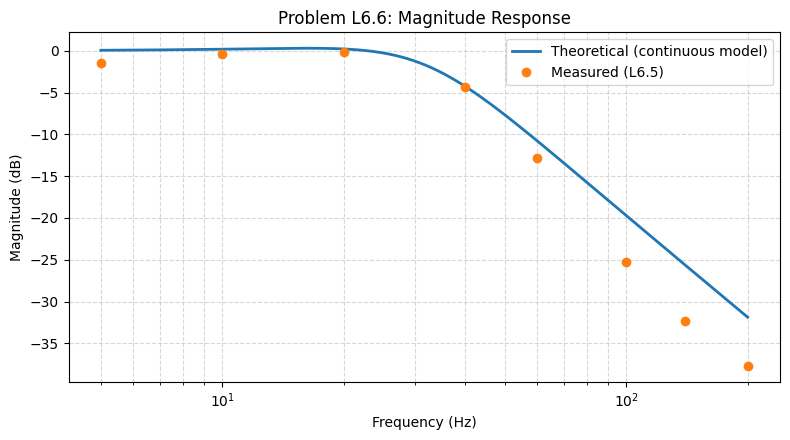

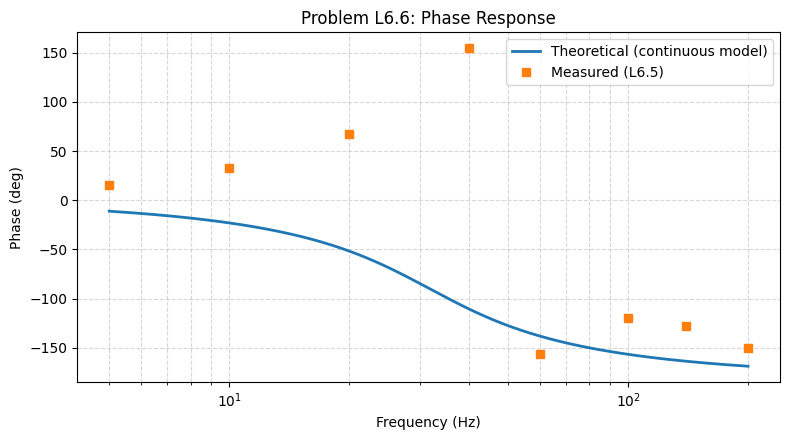

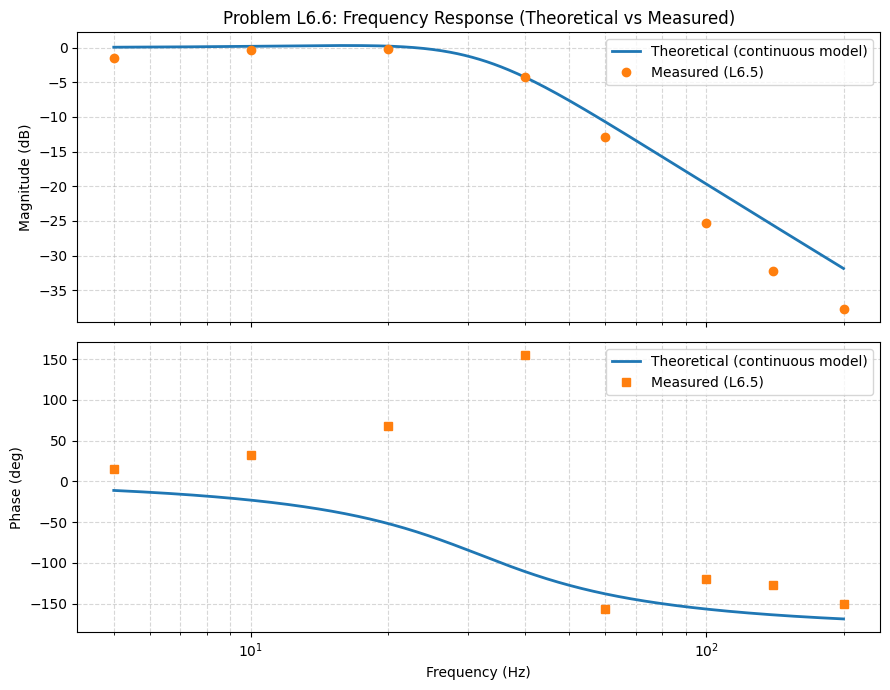


Saved charts:
- ../figures/Lab66-Magnitude-Comparison.png
- ../figures/Lab66-Phase-Comparison.png
- ../figures/Lab66-Bode-Comparison.png

Interpretation:
- Magnitude follows the expected low-pass roll-off trend and is generally close at low frequency.
- Larger mismatch at higher frequency is expected from sampling effects, ADC/DAC limits, and phase-noise sensitivity.
- Very small output amplitudes at high frequency increase measurement uncertainty, especially for phase.


In [3]:
# L6.6: Theoretical vs measured frequency response (magnitude and phase)
# - Build a continuous-time transfer function model (2nd-order estimate from step data).
# - Compute theoretical Bode data numerically (similar role as MATLAB bode()).
# - Plot magnitude (dB) and phase (deg) vs frequency (Hz, log scale).
# - Overlay measured oscilloscope data as discrete symbols.
# - Save chart images for the written report.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path

# --------------------------------------------------
# Measured data from Problem L6.5
# --------------------------------------------------
freq_hz_meas = np.array([5, 10, 20, 40, 60, 100, 140, 200], dtype=float)
vout_vpp = np.array([4.2330, 4.7900, 4.9141, 3.0537, 1.1369, 0.27218, 0.12172, 0.064914], dtype=float)
phase_deg_meas = np.array([15.347, 32.576, 67.855, 154.59, -156.44, -119.27, -127.62, -150.28], dtype=float)

vin_vpp = 5.0  # Input setting used during measurement (Vpp)
mag_ratio_meas = vout_vpp / vin_vpp
mag_db_meas = 20.0 * np.log10(mag_ratio_meas)

# --------------------------------------------------
# Build a theoretical continuous-time model
# Reuse num/den from previous cells if available; otherwise estimate from lab6.csv.
# --------------------------------------------------
if "num" in globals() and "den" in globals():
    num_model = np.asarray(num, dtype=float)
    den_model = np.asarray(den, dtype=float)
else:
    df = pd.read_csv("lab6.csv")
    t = df["t"].to_numpy() / 1000.0
    x = df["x"].to_numpy()
    y = df["y"].to_numpy()

    dx = np.diff(x)
    threshold = 0.5 * np.max(np.abs(dx))
    edge_indices = np.where(np.abs(dx) >= threshold)[0]
    rising_indices = np.where(dx >= threshold)[0]

    if len(rising_indices) > 0:
        step_index = rising_indices[np.argmax(dx[rising_indices])]
    else:
        step_index = edge_indices[np.argmax(np.abs(dx[edge_indices]))]

    start = max(step_index - 20, 0)
    default_end = min(step_index + 80, len(t) - 1)
    next_edges = edge_indices[edge_indices > step_index + 5]

    if len(next_edges) > 0:
        guard = max(10, int(0.8 * (next_edges[0] - step_index)))
        end = min(step_index + guard, default_end)
    else:
        end = default_end

    t_raw = t[start:end + 1]
    y_raw = y[start:end + 1]
    local_step_idx = (step_index + 1) - start

    pre_slice_start = max(local_step_idx - 10, 0)
    y_initial = np.mean(y_raw[pre_slice_start:local_step_idx])
    y_final = np.mean(y_raw[-10:])
    y_measured = (y_raw - y_initial) / (y_final - y_initial)

    t_step = t_raw[local_step_idx:] - t_raw[local_step_idx]
    y_step = y_measured[local_step_idx:]

    idx10 = np.where(y_step >= 0.1)[0][0]
    idx90 = np.where(y_step >= 0.9)[0][0]
    rise_time = t_step[idx90] - t_step[idx10]

    overshoot = max(0.0, np.max(y_step) - 1.0)
    if overshoot > 1e-6:
        ln_mp = np.log(overshoot)
        zeta = -ln_mp / np.sqrt(np.pi**2 + ln_mp**2)
    else:
        zeta = 0.70

    wn = 1.8 / max(rise_time, 1e-6)
    num_model = np.array([wn**2], dtype=float)
    den_model = np.array([1.0, 2.0 * zeta * wn, wn**2], dtype=float)

system = signal.TransferFunction(num_model, den_model)

# --------------------------------------------------
# Compute theoretical Bode data (separate from plotting)
# --------------------------------------------------
freq_hz_dense = np.logspace(np.log10(freq_hz_meas.min()), np.log10(freq_hz_meas.max()), 500)
omega_dense = 2.0 * np.pi * freq_hz_dense
omega_meas = 2.0 * np.pi * freq_hz_meas

# scipy.signal.bode returns magnitude in dB and phase in degrees
_, mag_db_theory_dense, phase_deg_theory_dense = signal.bode(system, w=omega_dense)
_, mag_db_theory_meas, phase_deg_theory_meas = signal.bode(system, w=omega_meas)

# --------------------------------------------------
# Wrap phase difference to [-180, 180] for meaningful comparison
# --------------------------------------------------
def wrap_deg(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

mag_err_db = mag_db_meas - mag_db_theory_meas
phase_err_deg = wrap_deg(phase_deg_meas - phase_deg_theory_meas)

results = pd.DataFrame({
    "Frequency_Hz": freq_hz_meas,
    "Mag_dB_Measured": mag_db_meas,
    "Mag_dB_Theory": mag_db_theory_meas,
    "Mag_Error_dB": mag_err_db,
    "Phase_deg_Measured": phase_deg_meas,
    "Phase_deg_Theory": phase_deg_theory_meas,
    "Phase_Error_deg": phase_err_deg,
})

print("L6.6 Theoretical vs Measured Frequency Response")
print(results.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()
print(f"RMS magnitude error (dB): {np.sqrt(np.mean(mag_err_db**2)):.3f}")
print(f"RMS phase error (deg): {np.sqrt(np.mean(phase_err_deg**2)):.3f}")

# --------------------------------------------------
# Plot charts and save image files for report use
# --------------------------------------------------
figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)
mag_path = figures_dir / "Lab66-Magnitude-Comparison.png"
phase_path = figures_dir / "Lab66-Phase-Comparison.png"
combined_path = figures_dir / "Lab66-Bode-Comparison.png"

# Magnitude-only chart
fig_mag, ax_mag = plt.subplots(figsize=(8, 4.5))
ax_mag.semilogx(freq_hz_dense, mag_db_theory_dense, linewidth=2.0, label="Theoretical (continuous model)")
ax_mag.semilogx(freq_hz_meas, mag_db_meas, "o", markersize=6, label="Measured (L6.5)")
ax_mag.set_xlabel("Frequency (Hz)")
ax_mag.set_ylabel("Magnitude (dB)")
ax_mag.set_title("Problem L6.6: Magnitude Response")
ax_mag.grid(True, which="both", linestyle="--", alpha=0.5)
ax_mag.legend()
fig_mag.tight_layout()
fig_mag.savefig(mag_path, dpi=300)
plt.show()

# Phase-only chart
fig_phase, ax_phase = plt.subplots(figsize=(8, 4.5))
ax_phase.semilogx(freq_hz_dense, phase_deg_theory_dense, linewidth=2.0, label="Theoretical (continuous model)")
ax_phase.semilogx(freq_hz_meas, phase_deg_meas, "s", markersize=6, label="Measured (L6.5)")
ax_phase.set_xlabel("Frequency (Hz)")
ax_phase.set_ylabel("Phase (deg)")
ax_phase.set_title("Problem L6.6: Phase Response")
ax_phase.grid(True, which="both", linestyle="--", alpha=0.5)
ax_phase.legend()
fig_phase.tight_layout()
fig_phase.savefig(phase_path, dpi=300)
plt.show()

# Combined Bode-style chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax1.semilogx(freq_hz_dense, mag_db_theory_dense, linewidth=2.0, label="Theoretical (continuous model)")
ax1.semilogx(freq_hz_meas, mag_db_meas, "o", markersize=6, label="Measured (L6.5)")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("Problem L6.6: Frequency Response (Theoretical vs Measured)")
ax1.grid(True, which="both", linestyle="--", alpha=0.5)
ax1.legend()

ax2.semilogx(freq_hz_dense, phase_deg_theory_dense, linewidth=2.0, label="Theoretical (continuous model)")
ax2.semilogx(freq_hz_meas, phase_deg_meas, "s", markersize=6, label="Measured (L6.5)")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Phase (deg)")
ax2.grid(True, which="both", linestyle="--", alpha=0.5)
ax2.legend()

fig.tight_layout()
fig.savefig(combined_path, dpi=300)
plt.show()

print(f"\nSaved charts:\n- {mag_path}\n- {phase_path}\n- {combined_path}")

# --------------------------------------------------
# Brief interpretation notes
# --------------------------------------------------
print("\nInterpretation:")
print("- Magnitude follows the expected low-pass roll-off trend and is generally close at low frequency.")
print("- Larger mismatch at higher frequency is expected from sampling effects, ADC/DAC limits, and phase-noise sensitivity.")
print("- Very small output amplitudes at high frequency increase measurement uncertainty, especially for phase.")